In [1]:
import xarray as xr

ds = xr.open_zarr(
    "s3://mlcast-source-datasets/IT-DPC-SRI/v0.1.0/italian-radar-dpc-sri.zarr/",
    storage_options={
        "anon": True,
        "endpoint_url": "https://object-store.os-api.cci2.ecmwf.int",
    },
    consolidated=True,
)

print(ds)

<xarray.Dataset> Size: 7TB
Dimensions:        (time: 1039785, y: 1400, x: 1200, missing_times: 15530)
Coordinates:
  * time           (time) datetime64[ns] 8MB 2010-01-01 ... 2025-12-31T23:55:00
  * y              (y) float64 11kB 6.495e+05 6.485e+05 ... -7.495e+05
  * x              (x) float64 10kB -5.995e+05 -5.985e+05 ... 5.995e+05
    lat            (y, x) float64 13MB dask.array<chunksize=(1400, 1200), meta=np.ndarray>
    lon            (y, x) float64 13MB dask.array<chunksize=(1400, 1200), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[ns] 124kB 2010-01-03T00:30:00 ....
Data variables:
    RR             (time, y, x) float32 7TB dask.array<chunksize=(1, 1400, 1200), meta=np.ndarray>
    crs            float32 4B ...
Attributes: (12/13)
    Author:                     Gabriele Franch
    Copyright:                  Dipartimento Protezione Civile (DPC) Nazional...
    Processed by:               Fondazione Bruno Kessler
    base_frequencies:           15min:2010-0

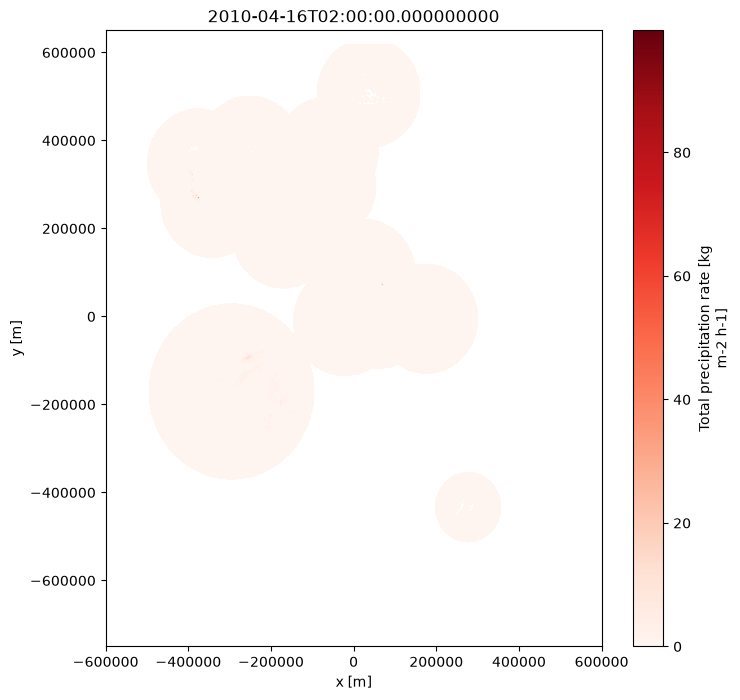

In [16]:
import matplotlib.pyplot as plt

frame = ds.RR.isel(time=10000
                )

plt.figure(figsize=(8,8))
frame.plot(cmap="Reds")
plt.title(str(frame.time.values))
plt.show()

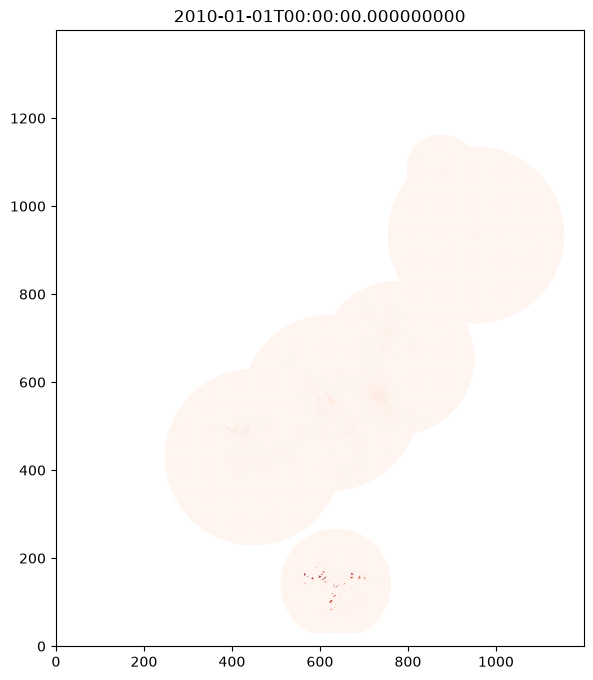

In [ ]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8,8))

im = ax.imshow(ds.RR.isel(time=0), origin="lower", cmap="Reds")

def update(i):
    im.set_data(ds.RR.isel(time=i))
    ax.set_title(str(ds.time[i].values))
    return [im]

ani = FuncAnimation(fig, update, frames=100, interval=10000)